# Diferencia en Diferencias ($Diff-in-Differences$): Aprovechando los Datos de Panel

¡Bienvenido a uno de los pilares más robustos de la inferencia causal! Hasta ahora, nos hemos centrado principalmente en datos de **corte transversal** ($cross-sectional$), que son como una "fotografía" instantánea de diferentes unidades en un momento dado. En este capítulo, daremos el salto a los **datos de panel**, que funcionan más como un "video": observamos a las mismas unidades repetidamente a lo largo del tiempo.

### ¿Por qué son tan potentes los datos de panel?

Imagina que quieres medir el impacto de una campaña de marketing offline. Si solo comparas ciudades con campaña frente a ciudades sin ella, te enfrentarás al problema de los **confundidores no observados**. Quizás las ciudades que eligieron la campaña son inherentemente más innovadoras o tienen una infraestructura diferente que no puedes medir.

El "superpoder" de los datos de panel es que nos permiten controlar por características que son **invariantes en el tiempo**, incluso si no las vemos. Si un factor (como la cultura de una ciudad) no cambia entre el "antes" y el "después", podemos eliminar su efecto simplemente restando los estados de la unidad en diferentes tiempos.

### Los Regímenes de Datos

1.  **Corte Transversal ($Cross-sectional$):** Cada unidad aparece una sola vez.
2.  **Corte Transversal Repetido:** Diferentes unidades en diferentes periodos (ej. una encuesta anual a personas distintas).
3.  **Datos de Panel ($Longitudinal$):** Las mismas unidades seguidas a través del tiempo. Es el estándar de oro para observar trayectorias individuales.

### La Intuición de Diferencia en Diferencias ($DiD$)

El estimador de $DiD$ busca responder: *¿Cuál fue el cambio en el grupo de tratamiento por encima del cambio en el grupo de control?*

Matemáticamente, lo expresamos como:

$$
\delta_{DiD} = (E[Y_{post} | T=1] - E[Y_{pre} | T=1]) - (E[Y_{post} | T=0] - E[Y_{pre} | T=0])
$$

Donde:
*   $T=1$ es el grupo que recibe el tratamiento.
*   $T=0$ es el grupo de control.
*   $pre$ y $post$ indican los periodos antes y después de la intervención.

En esencia, la primera resta $(E[Y_{post} | T=1] - E[Y_{pre} | T=1])$ captura el cambio total en el grupo tratado, pero este cambio incluye tanto el efecto del tratamiento como el paso del tiempo. La segunda resta captura la tendencia natural del tiempo en el grupo de control. Al restarlas, aislamos el **efecto causal neto**.

In [2]:
import polars as pl
import numpy as np

mkt_data = (
    pl.read_csv("../data/short_offline_mkt_south.csv")
    .with_columns(
        pl.col("date").str.to_datetime()
    )
)

mkt_data.head()

date,city,region,treated,tau,downloads,post
datetime[μs],i64,str,i64,f64,f64,i64
2021-05-01 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-02 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-03 00:00:00,5,"""S""",0,0.0,51.0,0
2021-05-04 00:00:00,5,"""S""",0,0.0,50.0,0
2021-05-05 00:00:00,5,"""S""",0,0.0,49.0,0


Primero se hizo el calculo del ATE de manera promediada, luego el efecto pro individuo, ahora el analizis de unidades a lo largo del tiempo.

In [3]:
(
    mkt_data
    .with_columns(
        w = pl.col("treated") * pl.col("post")
    )
    .group_by("w")
    .agg(
        pl.col("date").min().alias("date_min"),
        pl.col("date").max().alias("date_max"),
    )
)


w,date_min,date_max
i64,datetime[μs],datetime[μs]
0,2021-05-01 00:00:00,2021-06-01 00:00:00
1,2021-05-15 00:00:00,2021-06-01 00:00:00


La métrica que buscas estimar es el **Efecto Promedio del Tratamiento sobre los Tratados** (**ATT**, por sus siglas en inglés: *Average Treatment effect on the Treated*). Formalmente, el ATT responde a la pregunta:

> *¿Cuál es el efecto causal promedio de la campaña de marketing offline en las ciudades que realmente recibieron el tratamiento, después de que este ocurre?*

En notación matemática, el ATT se expresa como:

$$
ATT = E\left[ Y_{it}(1) - Y_{it}(0) \mid D_i = 1,\, t > T_{pre} \right]
$$

Donde:

- $Y_{it}(1)$: Descargas (o resultado de interés) para la ciudad $i$ en el tiempo $t$ **si** recibe el tratamiento.
- $Y_{it}(0)$: Descargas para la ciudad $i$ en el tiempo $t$ **si no** recibe el tratamiento.
- $D_i = 1$: La ciudad $i$ pertenece al grupo tratado.
- $t > T_{pre}$: Observaciones **después** del inicio de la campaña.

**Intuición:**  
El ATT compara, para las ciudades tratadas, el resultado observado tras la campaña con el resultado *contrafactual* (lo que habría pasado sin la campaña), promediando sobre todas las ciudades tratadas y periodos post-tratamiento.



## Canonical Difference-in-Differences

In [4]:
did_data = (
    mkt_data
    .group_by(["treated", "post"])
    .agg(
        pl.col("downloads").mean().alias("mean_downloads"),
        pl.col("date").min().alias("date_min"),
    )
)
did_data

treated,post,mean_downloads,date_min
i64,i64,f64,datetime[μs]
0,1,50.556878,2021-05-15 00:00:00
1,1,51.858025,2021-05-15 00:00:00
0,0,50.335034,2021-05-01 00:00:00
1,0,50.944444,2021-05-01 00:00:00


In [5]:
wide = (
    did_data
    .pivot(
        values="mean_downloads",
        index="treated",
        on="post",
        aggregate_function="first",
    )
)

t_pre  = wide.filter(pl.col("treated") == 1).select(pl.col("0")).item()
t_post = wide.filter(pl.col("treated") == 1).select(pl.col("1")).item()
c_pre  = wide.filter(pl.col("treated") == 0).select(pl.col("0")).item()
c_post = wide.filter(pl.col("treated") == 0).select(pl.col("1")).item()

att = t_post - t_pre - (c_post - c_pre)

print(f"El ATT estimado es: {att:.6f} descargas promedio por ciudad tratada.")


El ATT estimado es: 0.691736 descargas promedio por ciudad tratada.


In [6]:
wide

treated,1,0
i64,f64,f64
0,50.556878,50.335034
1,51.858025,50.944444


In [7]:

mkt_data.filter((pl.col("post") == 1) & (pl.col("treated") == 1)).select(pl.col("tau").mean()).item()

0.7660316402518459

### Diff-in-Diff with Outcome Growth

In [8]:
pre = mkt_data.filter(pl.col("post") == 0).group_by("city").agg(
    pl.col("downloads").mean().alias("mean_pre")
)
post = mkt_data.filter(pl.col("post") == 1).group_by("city").agg(
    pl.col("downloads").mean().alias("mean_post")
)

delta_y = pre.join(post, on="city").with_columns(
    (pl.col("mean_post") - pl.col("mean_pre")).alias("delta_y")
).join(
    mkt_data.group_by("city").agg(pl.col("treated").max()),
    on="city"
).sort("city")

delta_y

city,mean_pre,mean_post,delta_y,treated
i64,f64,f64,f64,i64
5,50.642857,50.166667,-0.47619,0
15,49.142857,49.166667,0.02381,0
20,48.785714,49.055556,0.269841,0
22,50.142857,50.166667,0.02381,0
28,49.571429,49.944444,0.373016,0
…,…,…,…,…
192,48.5,49.055556,0.555556,0
193,50.5,50.666667,0.166667,0
195,53.357143,53.777778,0.420635,0


In [9]:
(
    delta_y
    .filter(pl.col("treated") == 1)
    .select(pl.col("delta_y")
    .mean())
    .item() 
    -
    delta_y
    .filter(pl.col("treated") == 0)
    .select(pl.col("delta_y").mean())
    .item()
 )
 

0.6917359536407155

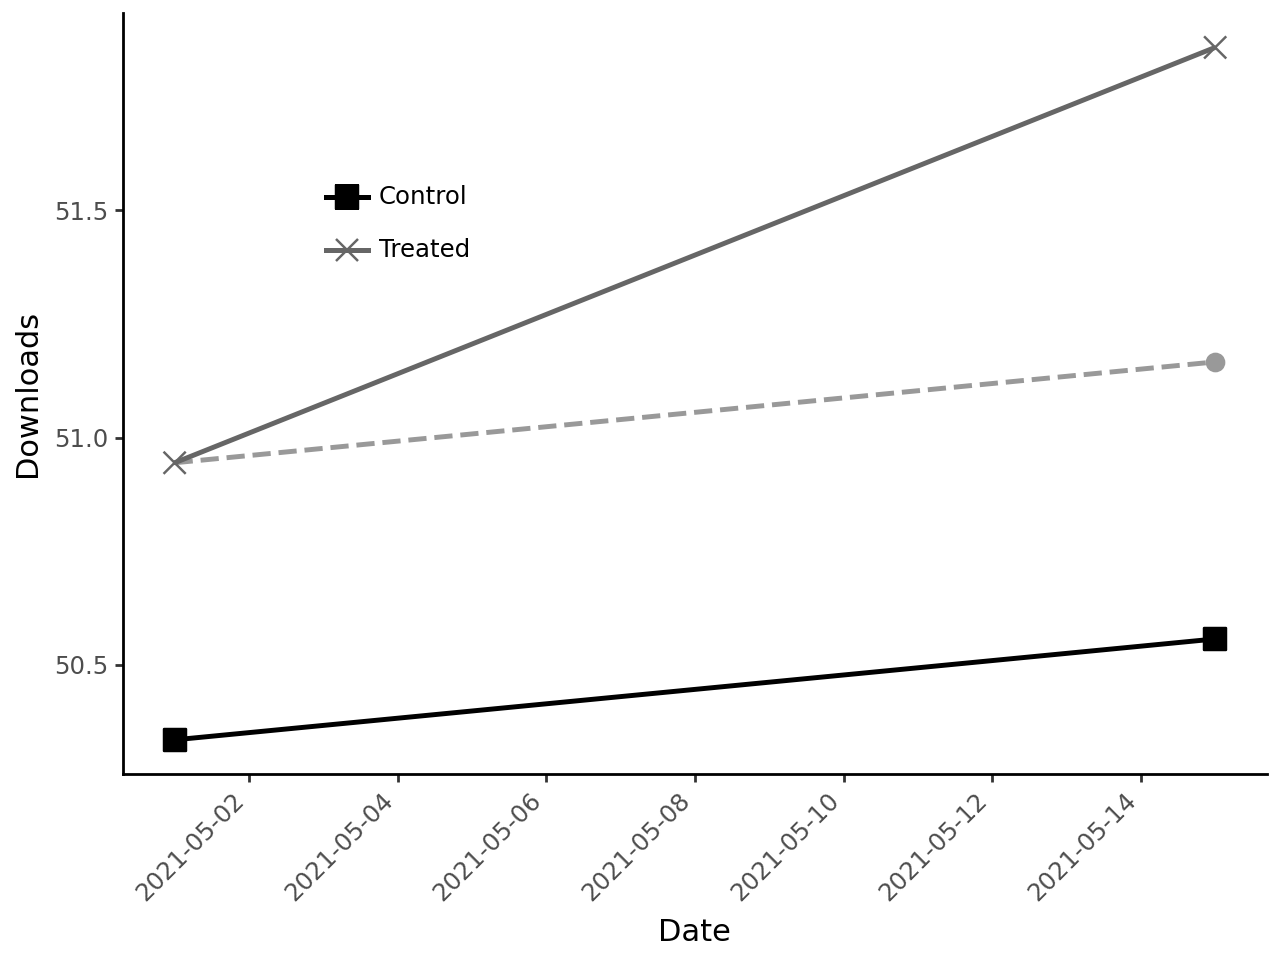

In [10]:
from plotnine import *

# Filtramos los valores observados
c_pre = did_data.filter((pl.col("treated") == 0) & (pl.col("post") == 0))["mean_downloads"].item()
c_post = did_data.filter((pl.col("treated") == 0) & (pl.col("post") == 1))["mean_downloads"].item()
t_pre = did_data.filter((pl.col("treated") == 1) & (pl.col("post") == 0))["mean_downloads"].item()

# Fechas para el eje X (tomamos la primera coincidencia de cada periodo)
date_pre = did_data.filter(pl.col("post") == 0)["date_min"].head(1).item()
date_post = did_data.filter(pl.col("post") == 1)["date_min"].head(1).item()

# Cálculo del Contrafactual (Tendencias Paralelas)
# Pendiente del Control + Inicio del Tratamiento
y0_est = t_pre + (c_post - c_pre)

# --- 2. Construcción de DataFrames para el Plot (100% Polars) ---

# A) DataFrame para la línea contrafactual (Dashed line)Ñ
cf_data = pl.DataFrame({
    "date_min": [date_pre, date_post],
    "mean_downloads": [t_pre, y0_est],
    "type": ["Counterfactual", "Counterfactual"]
})

# B) DataFrame principal con etiquetas legibles
# Usamos pl.when().then() para crear la columna categórica de etiquetas
main_data = did_data.with_columns(
    pl.when(pl.col("treated") == 1)
    .then(pl.lit("Treated"))
    .otherwise(pl.lit("Control"))
    .alias("type")
)

# --- 3. Visualización con Plotnine ---
# Plotnine acepta DataFrames de Polars directamente en versiones recientes

(
    ggplot()
    # CAPA 1: Línea Contrafactual (Gris punteada)
    + geom_line(data=cf_data, mapping=aes(x="date_min", y="mean_downloads"),
                linetype="dashed", color="#999999", size=1)
    + geom_point(data=cf_data.tail(1), mapping=aes(x="date_min", y="mean_downloads"),
                 color="#999999", size=3, shape="o") # Punto hueco/gris al final
    
    # CAPA 2: Datos Observados
    + geom_line(data=main_data, mapping=aes(x="date_min", y="mean_downloads", group="type", color="type"), size=1)
    + geom_point(data=main_data, mapping=aes(x="date_min", y="mean_downloads", color="type", shape="type"), size=4)
    
    # Estilos Manuales (Replicando la imagen)
    + scale_color_manual(values={"Control": "black", "Treated": "#666666"}) 
    + scale_shape_manual(values={"Control": "s", "Treated": "x"}) 
    
    # Formato
    + labs(x="Date", y="Downloads", color="", shape="") # Quitamos títulos de leyenda
    + theme_classic()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        legend_position=(0.2, 0.8), # Ajusta coordenadas (x,y) según tus datos 0-1
        legend_background=element_rect(fill="white", alpha=0) # Fondo transparente
    )
)

## Diff-in-Diff With OLS

In [11]:
did_data = (
    mkt_data
    .group_by(["city", "post"])
    .agg(
        pl.col("downloads").mean().alias("downloads"),
        pl.col("date").min().alias("date_min"),
        pl.col("treated").max().alias("treated"),
    )
).sort("city", descending=False)
did_data

city,post,downloads,date_min,treated
i64,i64,f64,datetime[μs],i64
5,0,50.642857,2021-05-01 00:00:00,0
5,1,50.166667,2021-05-15 00:00:00,0
15,0,49.142857,2021-05-01 00:00:00,0
15,1,49.166667,2021-05-15 00:00:00,0
20,1,49.055556,2021-05-15 00:00:00,0
…,…,…,…,…
195,1,53.777778,2021-05-15 00:00:00,0
196,0,52.214286,2021-05-01 00:00:00,0
196,1,52.333333,2021-05-15 00:00:00,0


In [12]:
import statsmodels.formula.api as smf

smf.ols(
    formula="downloads ~ treated*post",
    data=did_data.to_pandas()
).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,50.3350,0.252,199.760,0.000,49.835,50.835
treated,0.6094,0.600,1.016,0.312,-0.581,1.800
post,0.2218,0.356,0.623,0.535,-0.485,0.929
treated:post,0.6917,0.848,0.815,0.417,-0.992,2.375


## Diff-in-Diff with Fixed Effects



In [13]:
smf.ols(
    formula="downloads ~ C(city) + C(post) + treated*post",
    data=mkt_data.to_pandas()
).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,50.2198,0.249,201.309,0.000,49.730,50.709
C(city)[T.15],-1.2141,0.334,-3.639,0.000,-1.868,-0.560
C(city)[T.20],-1.4213,0.336,-4.236,0.000,-2.079,-0.763
C(city)[T.22],-0.2110,0.334,-0.632,0.527,-0.866,0.444
C(city)[T.28],-0.5668,0.339,-1.671,0.095,-1.232,0.099
C(city)[T.29],1.7689,0.336,5.260,0.000,1.109,2.429
C(city)[T.30],1.28e+11,2.96e+11,0.433,0.665,-4.52e+11,7.08e+11
C(city)[T.31],-0.0505,0.335,-0.151,0.880,-0.707,0.606
C(city)[T.36],1.7520,0.333,5.254,0.000,1.098,2.406
C(city)[T.39],1.6096,0.335,4.799,0.000,0.952,2.268


## Multiple Time Periods 

In [14]:
import polars as pl
from plotnine import *

# 1. Preparar datos para el Heatmap
# Queremos que cada ciudad tenga un valor de "sort_val" basado en su estado final
heat_data = (
    mkt_data
    .with_columns([
        pl.col("date").dt.strftime("%Y-%m-%d").alias("date_str"),
        (pl.col("treated") * pl.col("post")).alias("is_treated")
    ])
    .with_columns(
        # Buscamos el valor de is_treated solo para la última fecha, por ciudad
        sort_val = pl.col("is_treated")
                   .filter(pl.col("date") == pl.col("date").max())
                   .max() # Tomamos el valor (0 o 1)
                   .over("city") # Lo expandimos a todas las filas de esa ciudad
    )
)

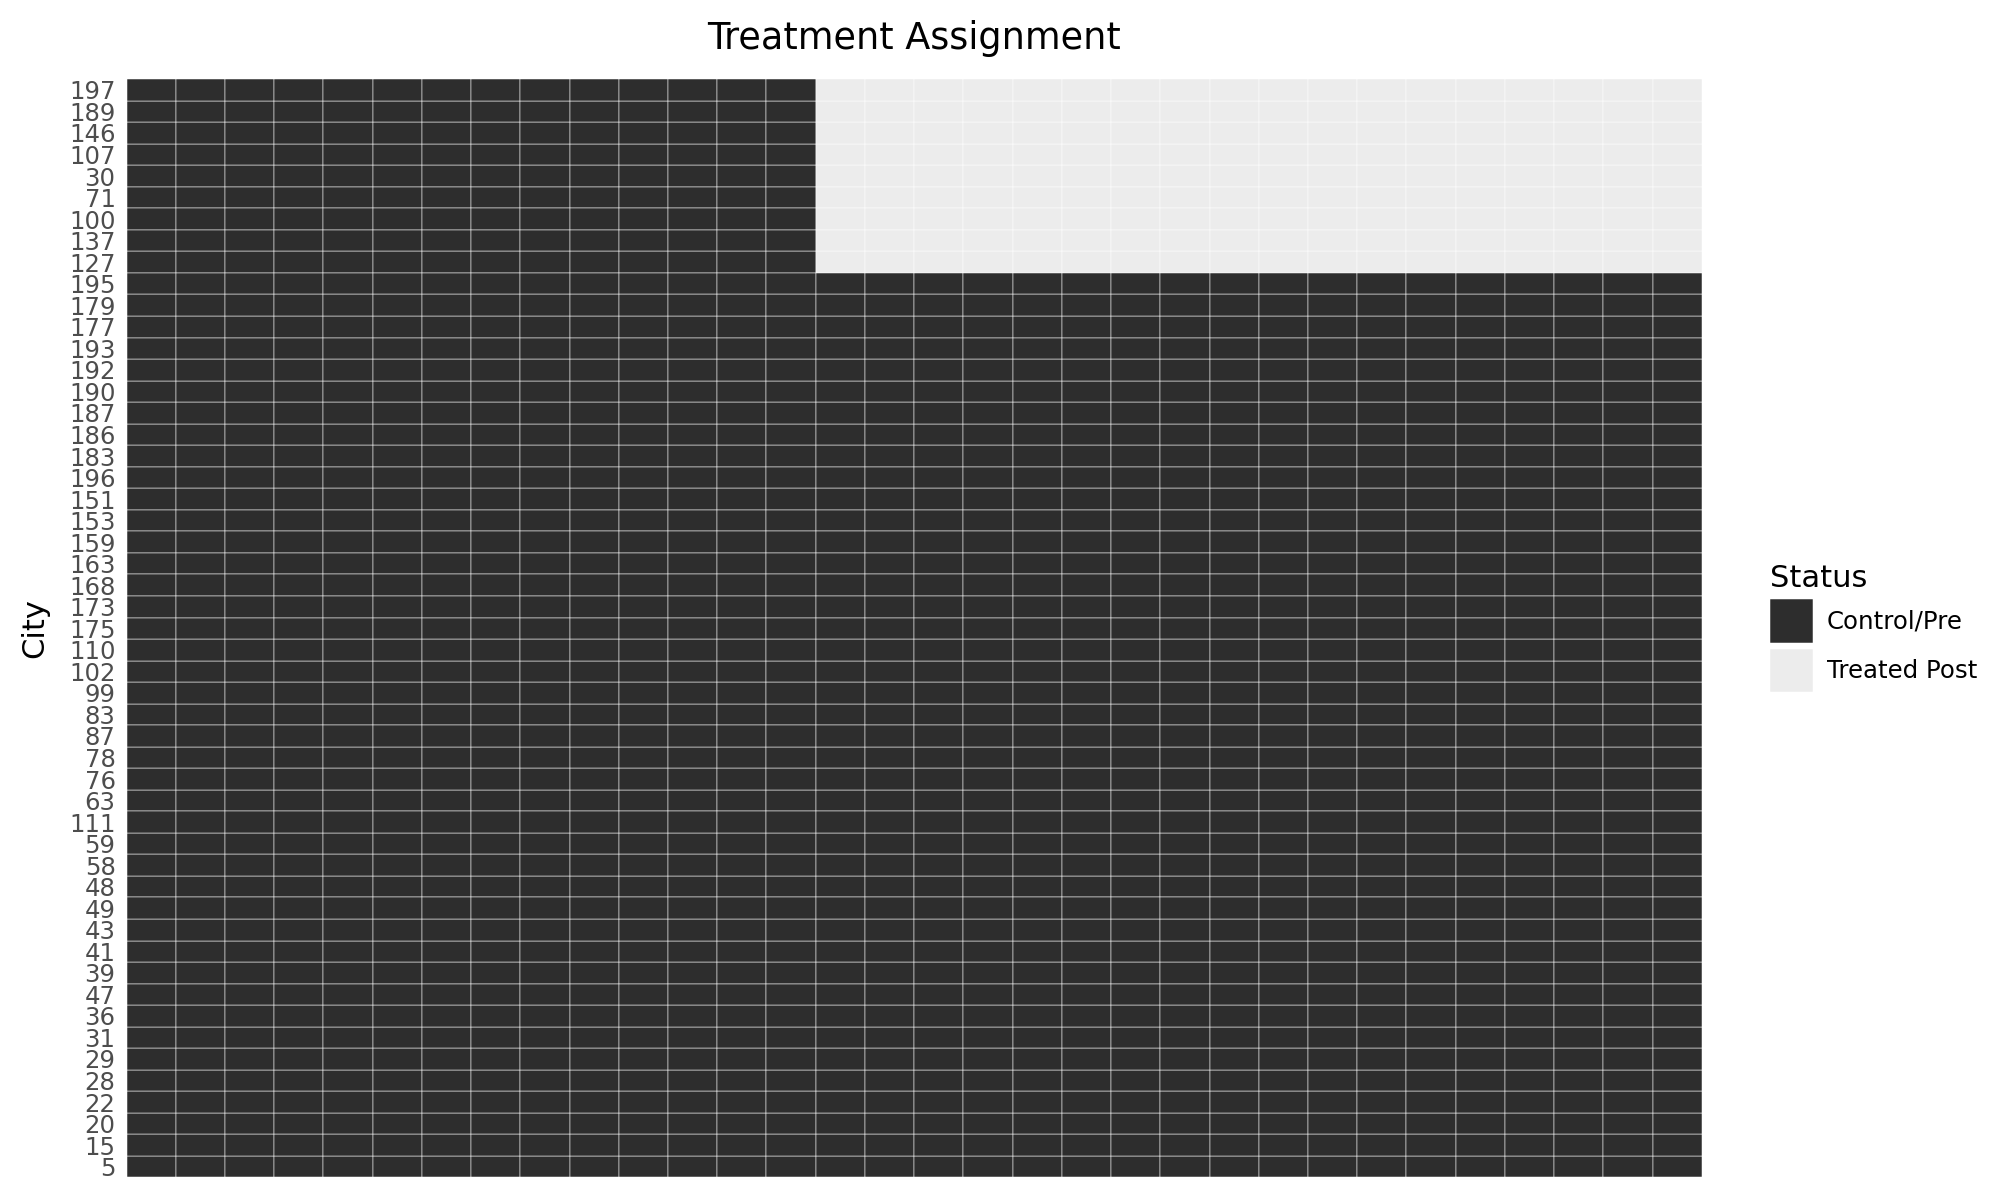

In [15]:
(
    ggplot(heat_data, aes(x="date_str", y="reorder(city, sort_val)", fill="factor(is_treated)"))
    + geom_tile(color="white", size=0.1) # Líneas blancas para separar celdas
    + scale_fill_manual(values=["#2d2d2d", "#ececec"], labels=["Control/Pre", "Treated Post"])
    + labs(title="Treatment Assignment", x="", y="City", fill="Status")
    + theme_minimal()
    + theme(
        axis_text_x=element_blank(),
        axis_ticks_x=element_blank(),
        figure_size=(10, 6),
        panel_grid=element_blank()
    )
)

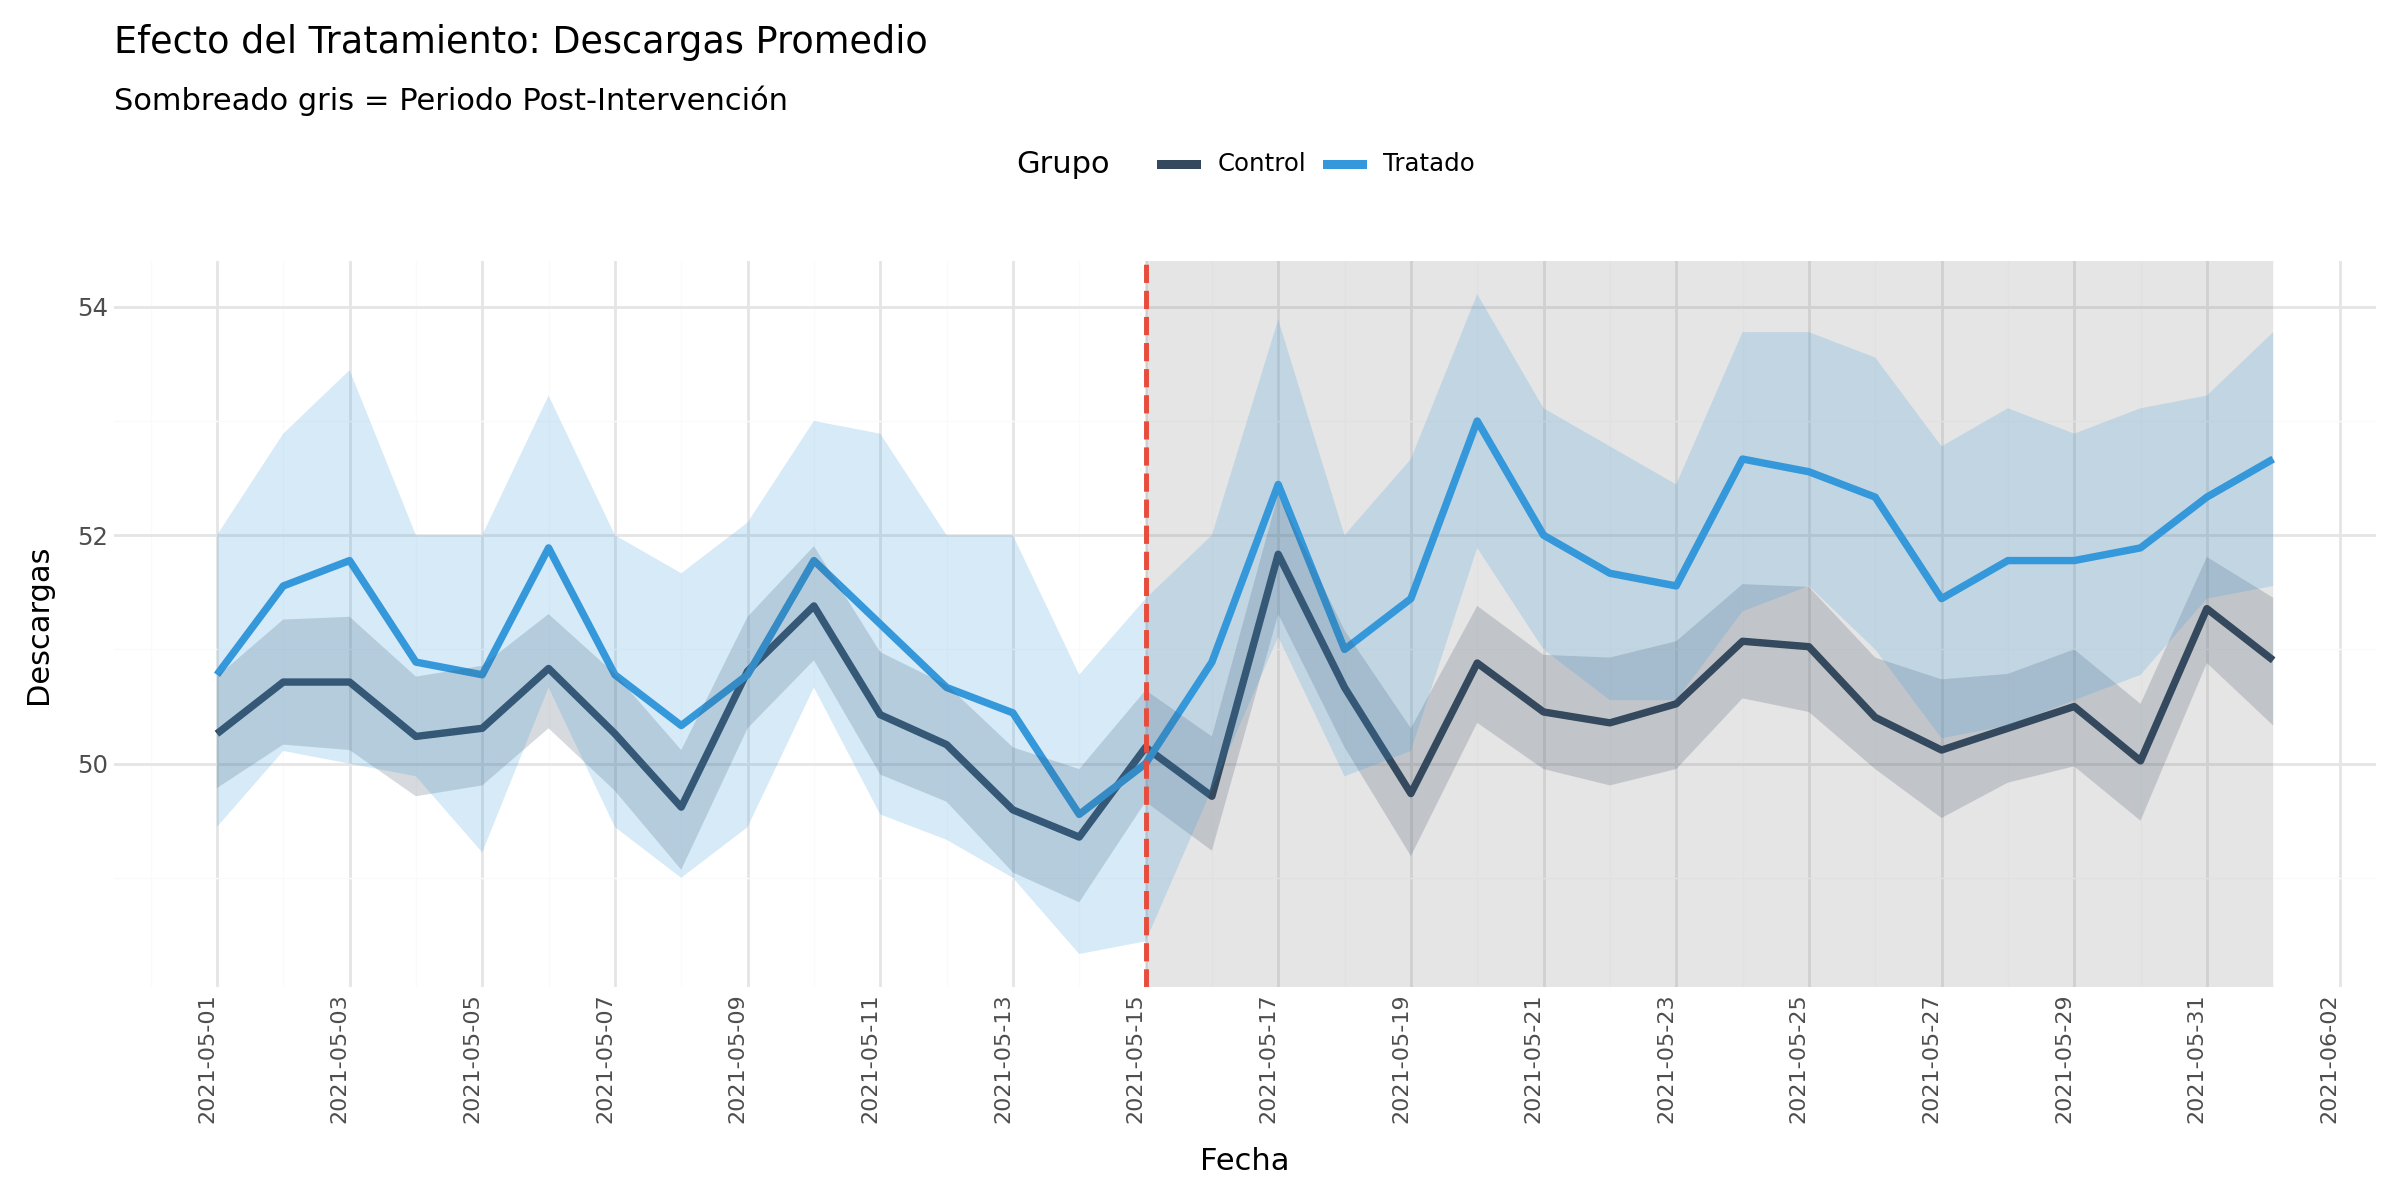

In [16]:
import polars as pl
import numpy as np
from plotnine import *
from datetime import date

# 1. Obtener las fechas como objetos de fecha reales, no strings
# La fecha de intervención es el 15 de mayo de 2021
fecha_intervencion_dt = date(2021, 5, 15)
# La última fecha la sacamos directamente de la columna de fechas original
fecha_final_dt = heat_data["date"].max()

(
    # --- CAMBIO CLAVE: Usamos x="date" en lugar de "date_str" ---
    ggplot(heat_data, aes(x="date", y="downloads", group="treated"))
    
    # 2. ANNOTATE: Usamos los objetos de fecha para los límites
    + annotate("rect", 
               xmin=fecha_intervencion_dt, 
               xmax=fecha_final_dt, 
               ymin=-np.inf, 
               ymax=np.inf, 
               fill="gray", 
               alpha=0.2)
    
    # 3. Líneas y Ribbons (igual que antes)
    + stat_summary(aes(color="factor(treated)"), fun_y=np.mean, geom="line", size=1.5)
    + stat_summary(aes(fill="factor(treated)"), fun_data="mean_cl_boot", geom="ribbon", alpha=0.2)
    
    # 4. Línea vertical: Usamos el objeto de fecha
    + geom_vline(xintercept=fecha_intervencion_dt, linetype="dashed", color="#e74c3c", size=1)
    
    # 5. Estética, Etiquetas y Formato de Fecha
    + scale_color_manual(values=["#34495e", "#3498db"], labels=["Control", "Tratado"])
    + scale_fill_manual(values=["#34495e", "#3498db"], guide=None)
    
    # --- NUEVO: Formateamos el eje X para que se vea bien ---
    + scale_x_date(date_labels="%Y-%m-%d", date_breaks="2 days")
    
    + labs(
        title="Efecto del Tratamiento: Descargas Promedio",
        subtitle="Sombreado gris = Periodo Post-Intervención",
        x="Fecha",
        y="Descargas",
        color="Grupo"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=90, hjust=1, size=8),
        figure_size=(12, 6),
        legend_position="top"
    )
)



## Inference

In [17]:
m = smf.ols(
    formula="downloads ~ C(city) + C(date) + treated:post",
    data=mkt_data.to_pandas()
).fit(cov_kwds={'groups': mkt_data['city'].to_pandas()}, cov_type='cluster')

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407319


0    0.296101
1    1.087370
Name: treated:post, dtype: float64

In [18]:
m = smf.ols(
    formula="downloads ~ treated:post + C(city) + C(date)",
    data=mkt_data.to_pandas()
).fit()
print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407319


0    0.478014
1    0.905457
Name: treated:post, dtype: float64

In [19]:
m = smf.ols(
    formula="downloads ~ C(city) + C(date_min) + treated:post",
    data=did_data.to_pandas()
).fit(cov_kwds={'groups': did_data['city'].to_pandas()}, cov_type='cluster')

print("ATT:", m.params["treated:post"])
m.conf_int().loc["treated:post"]

ATT: 0.6917359536407118


0    0.138188
1    1.245284
Name: treated:post, dtype: float64

**Comparación de Estrategias de Inferencia en Diff-in-Diff**

| Estrategia                          | Intervalo de Confianza         | Riesgo Principal                        |
|--------------------------------------|-------------------------------|-----------------------------------------|
| **Regresión Diaria sin Clúster**     | Muy estrecho                  | Falso optimismo (subestima la incertidumbre) |
| **Regresión Agregada con Clúster**   | Muy ancho                     | Exceso de cautela (puedes perder efectos reales) |
| **Regresión Diaria con Clúster**     | Balanceado y honesto          | Aprovecha la información temporal sin subestimar la incertidumbre |

**Conclusión:**  
La regresión diaria con errores estándar agrupados (clúster) es el enfoque más recomendable: utiliza toda la variabilidad temporal y ajusta correctamente la incertidumbre, evitando tanto el falso optimismo como la excesiva cautela.

In [20]:
def block_sample(df, unit_col):
    # Si el DataFrame tiene el método to_pandas, lo convertimos a pandas para facilitar el muestreo
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()
    units = df[unit_col].unique()
    sample = np.random.choice(units, size=len(units), replace=True)

    return (df
            .set_index(unit_col)
            .loc[sample]
            .reset_index(level=[unit_col])
            )

from joblib import Parallel, delayed

def block_bootstrap(data, est_fn, unit_col,
                    rounds=200, seed=123, pcts=[2.5, 97.5]):
    np.random.seed(seed)

    stats = Parallel(n_jobs=-1)(
        delayed(est_fn)(block_sample(data, unit_col))
        for _ in range(rounds)
    )

    return np.percentile(stats, pcts)

In [21]:
def est_fn(df):
    m = smf.ols(
        formula="downloads ~ C(city) + C(date) + treated:post",
        data=df
    ).fit()
    return m.params["treated:post"]

block_bootstrap(mkt_data, est_fn, unit_col="city")

array([0.23162214, 1.14002646])

## Identification Assumptions

#### Paralell Trends


$$ATT = \underbrace{(E[Y | D=1, Post=1] - E[Y | D=1, Post=0])}_{\text{Cambio en el Tratado}} - \underbrace{(E[Y | D=0, Post=1] - E[Y | D=0, Post=0])}_{\text{Cambio en el Control}}$$

$$
Y_{it} = \beta_0 + \beta_1 D_i + \beta_2 Post_t + \beta_3 (D_i \times Post_t) + \epsilon_{it}
$$

**¿Qué significa cada coeficiente?**

- $\beta_0$: El nivel base del grupo de control antes del tratamiento.
- $\beta_1$: La diferencia inicial (sesgo) entre tratado y control antes de empezar.
- $\beta_2$: La tendencia o crecimiento natural del mercado a través del tiempo.
- $\beta_3$: Este es el DiD (ATT). Es el efecto adicional que ocurre solo cuando se es del grupo tratado **y** se está en el periodo post.

## No Anticipation Assumption and SUTVA

SUTVA se refiere a la "Stable Unit Treatment Value Assumption" (Suposición de Valor Estable del Tratamiento para las Unidades). Esta suposición tiene dos componentes clave:

1. **No Interferencia entre Unidades:** El tratamiento aplicado a una unidad no afecta el resultado de otra unidad. Por ejemplo, si una ciudad recibe una campaña de marketing, esto no debería influir en las descargas de aplicaciones en otra ciudad que no recibió la campaña.

2. **Supuesto de no anticipación:** Las unidades no anticipan el tratamiento antes de que ocurra. Es decir, el comportamiento de las unidades no cambia antes de la implementación del tratamiento debido a expectativas sobre el mismo.

## Strict Exogenity

### Resumen Matemático

El modelo de efectos fijos se expresa así:

$$
Y_{it} = \alpha_{i} + \beta W_{it} + \epsilon_{it}
$$

Donde:

- $Y_{it}$: Resultado observado (por ejemplo, descargas) para la ciudad $i$ en el momento $t$.
- $\alpha_{i}$: Efecto fijo de la ciudad. Captura todas las variables invariantes en el tiempo (cultura, leyes, población).
- $W_{it}$: Variable de tratamiento (1 si hay oferta, 0 si no).
- $\beta$: El efecto causal que queremos estimar.
- $\epsilon_{it}$: Error o residuo, que debe cumplir la **Exogeneidad Estricta**:  
    $$
    E[\epsilon_{it} \mid W, \alpha] = 0
    $$

---

### Pequeño Ejemplo

Imagina que comparas las descargas de combustible en Ciudad A (metrópolis con mucho tráfico) y Ciudad B (pueblo pequeño).

- **Problema:** Si solo comparas descargas, Ciudad A siempre tendrá más por su tamaño de población, no por tus ofertas.
- **Solución (Efectos Fijos):** El modelo asigna un "punto de partida" ($\alpha_{i}$) para cada ciudad.  
    - Para Ciudad A será alto (ej. 1000), para Ciudad B bajo (ej. 100).

**Violación del Supuesto (Efecto de Arrastre):**  
Si lanzas una oferta el lunes y genera descargas el martes, pero el modelo no tiene una variable de "oferta" para el martes, ese aumento se va al error ($\epsilon_{it}$).  
Como ese error ahora "sabe" que hubo una oferta el lunes, se rompe la independencia matemática y tu cálculo de $\beta$ será sesgado.

---

### Visualización con el DAG

En el diagrama causal, la **Ciudad** (nodo rojo) actúa como un escudo que bloquea la influencia de la cultura o leyes sobre el resultado, dejando el camino libre para observar solo el efecto de $W$ (Tratamiento) sobre $Y$ (Resultado) en cada tiempo $T$.


## Effect Dynamics over Time


In [22]:
def did_date(df, date):
    df_date = (df
               .filter((pl.col("date") == date) | (pl.col("post") == 0))
               .filter(pl.col("date") <= date)
               .with_columns(
                   post = pl.when(pl.col("date") == date).then(1).otherwise(0)
               ))
    
    m = smf.ols(
        'downloads ~ I(treated*post) + C(city) + C(date)', data=df_date.to_pandas()
    ).fit(cov_type='cluster', cov_kwds={'groups': df_date['city']})

    att = m.params["I(treated * post)"]
    ci = m.conf_int().loc["I(treated * post)"]

    return pl.DataFrame({"att": [att], "ci_lower": [ci[0]], "ci_upper": [ci[1]], "date": pl.Series([date])})

In [23]:
# 1. Función para estimar el ATT puntual en una fecha específica
def did_date(df, target_date):
    """
    Conceptualmente, estimamos: 
    Y_it = α_i + γ_t + δ_t * (D_i * 1{t = target_date}) + ε_it
    donde:
    - α_i: Efecto fijo de ciudad (controla por factores invariantes en el tiempo).
    - γ_t: Efecto fijo de tiempo (controla por shocks globales en esa fecha).
    - δ_t: El ATT específico para la fecha de interés.
    """
    
    # Filtramos los datos para incluir solo la fecha objetivo Y el periodo pre-tratamiento
    # Matemáticamente, comparamos el estado de las unidades en 'target_date' 
    # contra su propio historial antes de que cualquier intervención ocurriera.
    df_temp = (
        df.filter(
            ((pl.col("date") == target_date) | (pl.col("post") == 0)) & 
            (pl.col("date") <= target_date) 
        )
        .with_columns(
            # Definimos el regresor de interés: D_i * I(t = target_date)
            # Este coeficiente capturará la desviación de la tendencia en ese día exacto.
            post_temp = pl.when(pl.col("date") == target_date).then(1).otherwise(0)
        )
    )
    
    # Estimamos mediante OLS con errores estándar agrupados (Clustered SE)
    # El clustering por ciudad es vital porque las observaciones de una misma ciudad 
    # a lo largo del tiempo están correlacionadas (autocorrelación).
    model = smf.ols(
        "downloads ~ I(treated * post_temp) + C(city) + C(date)", 
        data=df_temp.to_pandas()
    ).fit(cov_type='cluster', cov_kwds={'groups': df_temp['city'].to_numpy()})

    # Extraemos el coeficiente δ_t y su intervalo de confianza al 95%
    att = model.params["I(treated * post_temp)"]
    ci = model.conf_int().loc["I(treated * post_temp)"]

    return pl.DataFrame({
        "date": [target_date],
        "att": [att], 
        "ci_lower": [ci[0]], 
        "ci_upper": [ci[1]]
    })

# 2. Identificamos todas las fechas para el análisis (Placebos + Efectos Reales)
# Incluir fechas pre-tratamiento nos permite testear el supuesto de Tendencias Paralelas.
# Si t < fecha_intervención, esperamos que δ_t ≈ 0 (Efectos Placebo).
all_dates = mkt_data["date"].unique().sort()
target_dates = all_dates[1:] # Omitimos la primera como referencia basal

# 3. Iteración y consolidación de los efectos dinámicos
dynamic_atts = pl.concat([
    did_date(mkt_data, dt) for dt in target_dates
])

dynamic_atts

date,att,ci_lower,ci_upper
datetime[μs],f64,f64,f64
2021-05-02 00:00:00,0.325397,-0.491741,1.142534
2021-05-03 00:00:00,0.384921,-0.388389,1.158231
2021-05-04 00:00:00,-0.156085,-1.247491,0.935321
2021-05-05 00:00:00,-0.299603,-0.949935,0.350729
2021-05-06 00:00:00,0.347619,0.013115,0.682123
…,…,…,…
2021-05-28 00:00:00,0.858844,0.128426,1.589261
2021-05-29 00:00:00,0.668367,0.0332,1.303535
2021-05-30 00:00:00,1.255669,0.525612,1.985726


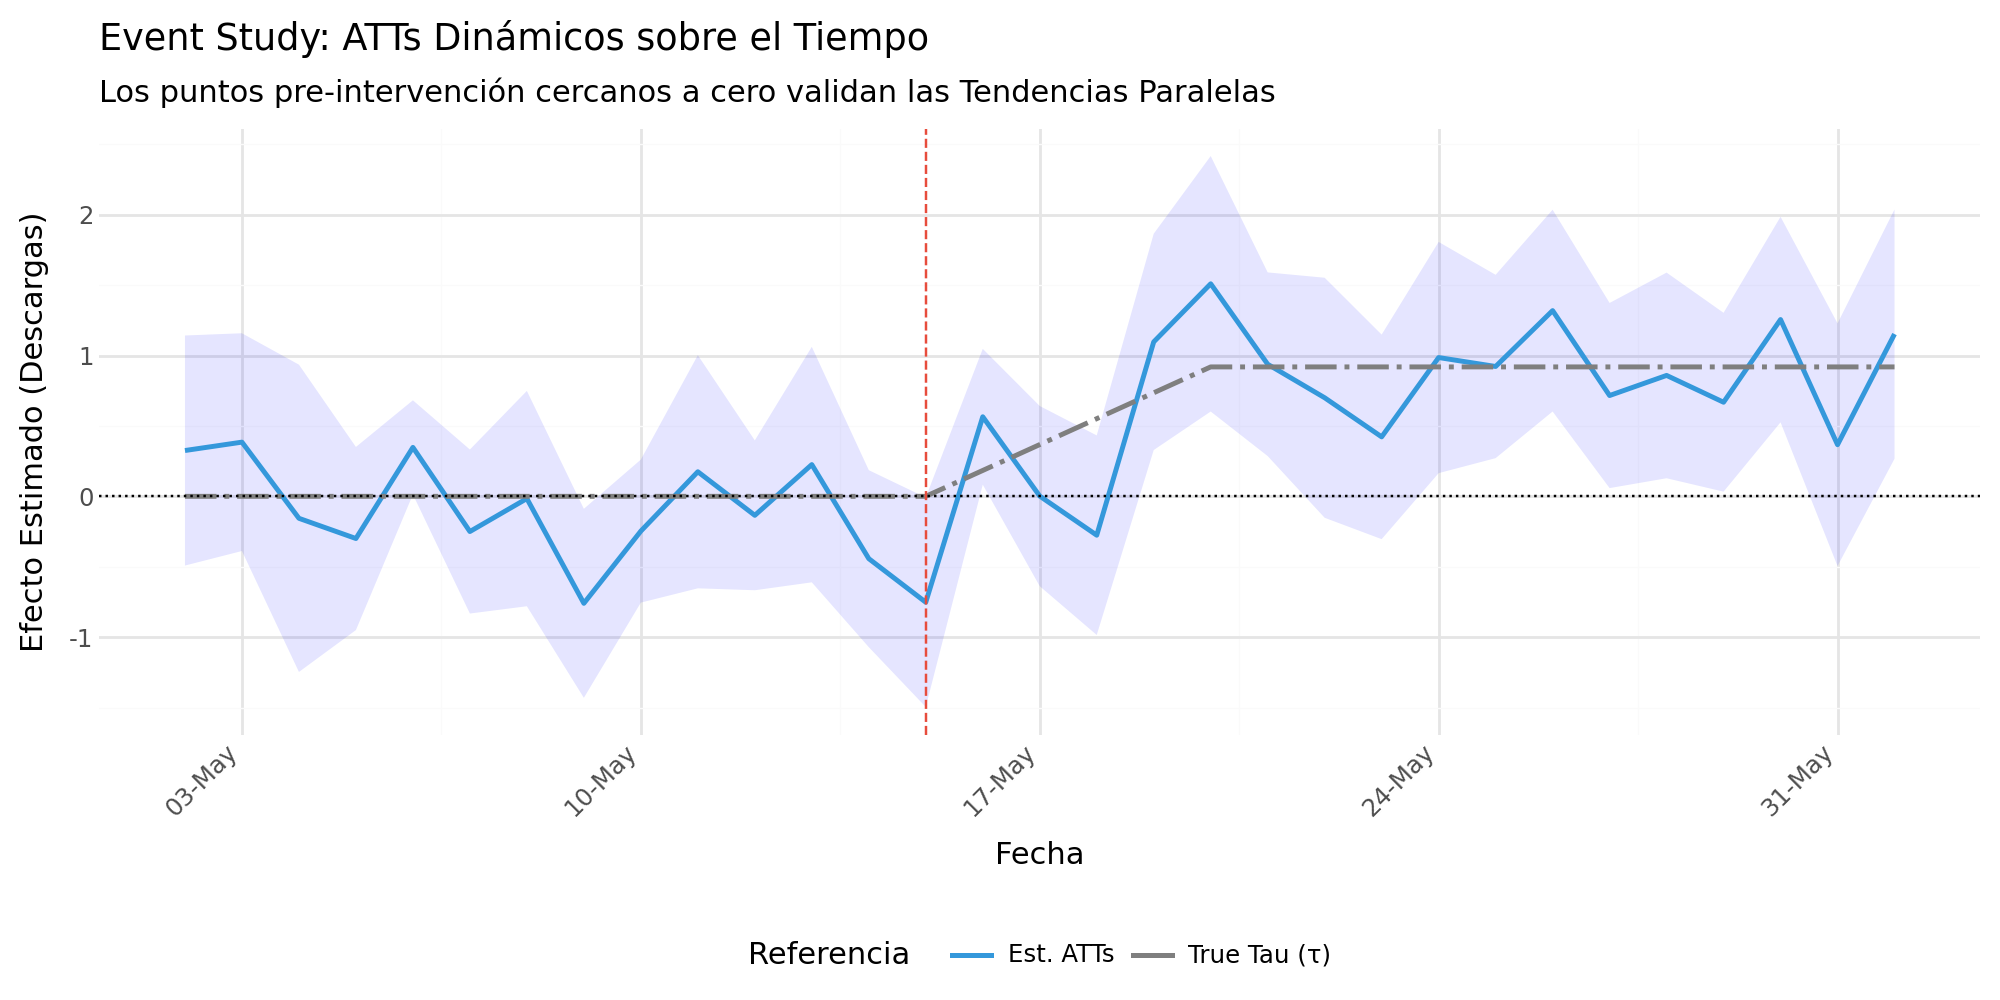

In [24]:

# 1. Extraemos el efecto real (ground truth) del dataset para comparar
# Filtramos solo el grupo tratado y promediamos el tau por fecha
ground_truth = (
    mkt_data
    .filter(pl.col("treated") == 1)
    .group_by("date")
    .agg(pl.col("tau").mean())
    .sort("date")
)

# 2. Construcción del gráfico dinámico
(
    ggplot(dynamic_atts, aes(x="date", y="att"))
    # Intervalo de confianza (Incertidumbre)
    + geom_ribbon(aes(ymin="ci_lower", ymax="ci_upper"), fill="blue", alpha=0.1)
    
    # Línea de los ATTs estimados
    + geom_line(aes(color="'Est. ATTs'"), size=1)
    
    # Línea del efecto real (Tau) - Saltamos la primera fecha para coincidir con dynamic_atts
    + geom_line(data=ground_truth.slice(1), 
                mapping=aes(x="date", y="tau", color="'True Tau (\\u03C4)'"), 
                linetype="dashdot", size=1)
    
    # Referencias visuales
    + geom_vline(xintercept=date(2021, 5, 15), linetype="dashed", color="#e74c3c") # Intervención
    + geom_hline(yintercept=0, linetype="dotted", color="black") # Referencia cero
    
    # Estética y Etiquetas
    + scale_color_manual(values={"Est. ATTs": "#3498db", "True Tau (\\u03C4)": "#7f8c8d"})
    + scale_x_date(date_labels="%d-%b", date_breaks="1 week")
    + labs(
        title="Event Study: ATTs Dinámicos sobre el Tiempo",
        subtitle="Los puntos pre-intervención cercanos a cero validan las Tendencias Paralelas",
        x="Fecha",
        y="Efecto Estimado (Descargas)",
        color="Referencia"
    )
    + theme_minimal()
    + theme(
        axis_text_x=element_text(rotation=45, hjust=1),
        figure_size=(10, 5),
        legend_position="bottom"
    )
)

## Diff-in-Diff con Covariables

En la práctica, a veces la suposición de **tendencias paralelas** no se cumple de manera incondicional, pero sí puede ser válida **condicionalmente** en ciertas características observadas (covariables) $X$. Es decir, los grupos tratado y control podrían tener trayectorias distintas en promedio, pero similares si comparamos unidades con valores similares de $X$.

**¿Qué cambia?**  
En vez de asumir:
$$
E[Y_{it}(0) \mid D=1] - E[Y_{it}(0) \mid D=0] = \text{constante}
$$

Asumimos:
$$
E[Y_{it}(0) \mid D=1, X] - E[Y_{it}(0) \mid D=0, X] = \text{constante para cada } X
$$

Esto se llama **tendencia paralela condicional**. El modelo Diff-in-Diff con covariables ajusta por $X$ para comparar "manzanas con manzanas".



In [25]:
mkt_data_all = (pl.read_csv("../data/short_offline_mkt_all_regions.csv").with_columns(
    pl.col("date").str.to_datetime()
))
mkt_data_all.head()

date,city,region,treated,tau,downloads,post
datetime[μs],i64,str,i64,f64,f64,i64
2021-05-01 00:00:00,1,"""W""",0,0.0,27.0,0
2021-05-02 00:00:00,1,"""W""",0,0.0,28.0,0
2021-05-03 00:00:00,1,"""W""",0,0.0,28.0,0
2021-05-04 00:00:00,1,"""W""",0,0.0,26.0,0
2021-05-05 00:00:00,1,"""W""",0,0.0,28.0,0


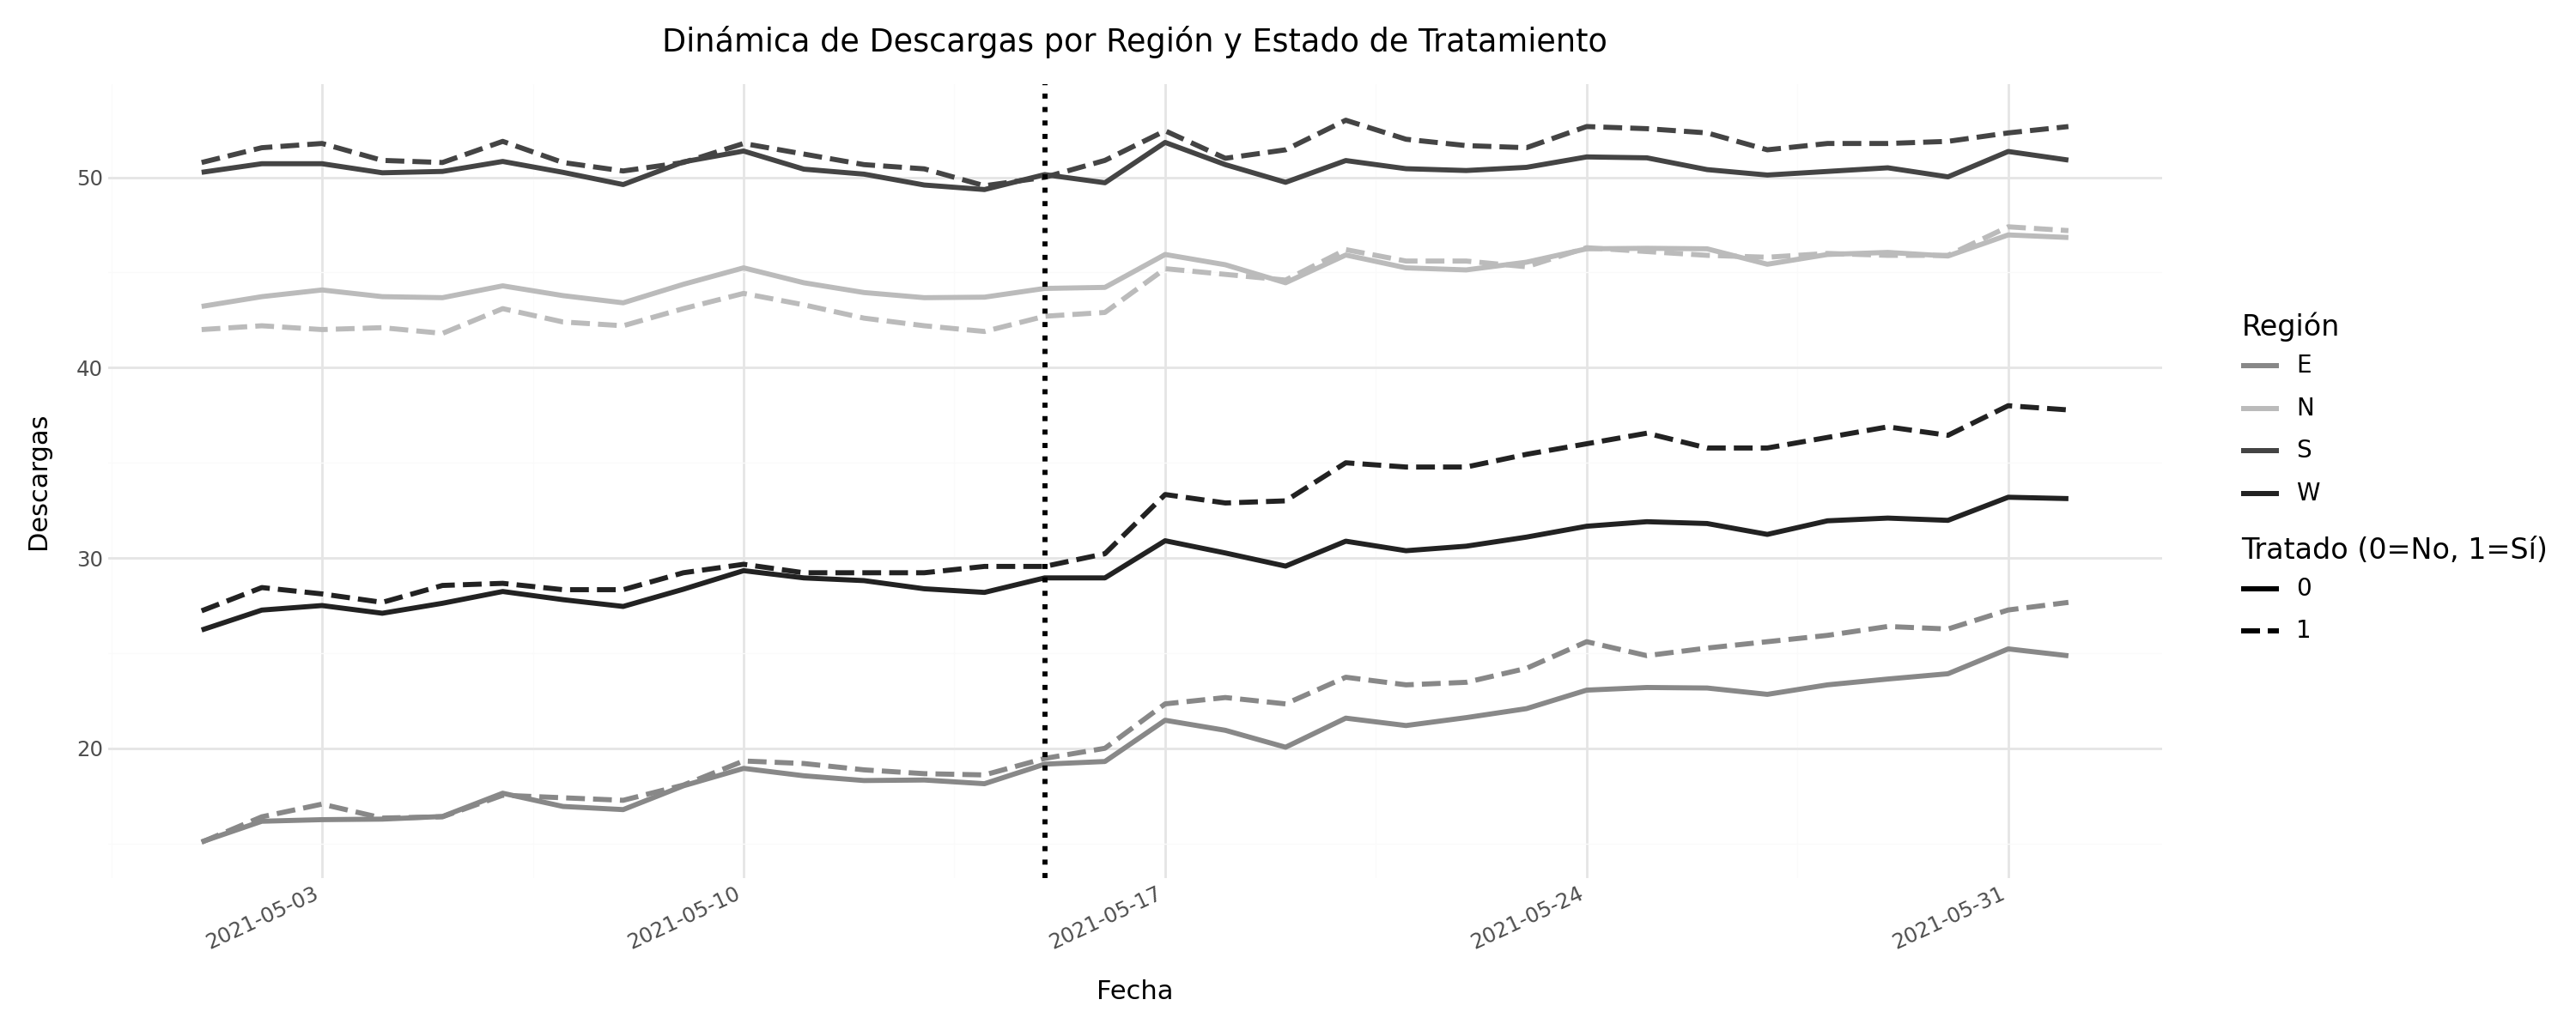

In [26]:
# Creamos una columna que combina región y tratado (como string)
mkt_data_all = mkt_data_all.with_columns(
    (pl.col("region") + "_" + pl.col("treated").cast(pl.Utf8)).alias("region_treated")
)

(
    # Usamos factor(treated) para que plotnine asigne estilos de línea automáticamente (solid, dashed, etc.)
    ggplot(mkt_data_all, aes(x="date", y="downloads", color="region", linetype="factor(treated)", group="region_treated"))
    + stat_summary(
        fun_y=np.mean, # Calculamos el promedio diario por grupo
        geom="line",
        size=1.2
    )
    # Línea vertical en la fecha de intervención (2021-05-15)
    + geom_vline(xintercept=date_post, linetype="dotted", color="black", size=1.2)
    # Paleta de grises para diferenciar visualmente las regiones
    + scale_color_manual(values=["#888888", "#bbbbbb", "#444444", "#222222"])
    + labs(
        x="Fecha", 
        y="Descargas", 
        color="Región", 
        linetype="Tratado (0=No, 1=Sí)", 
        title="Dinámica de Descargas por Región y Estado de Tratamiento"
    )
    + theme_minimal()
    + theme(
        figure_size=(15, 6),
        axis_text_x=element_text(rotation=25, hjust=1),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10)
    )
)

Puede existir que por ejemplo por ciudad no exitan tendencias paralelas, pero si se agrupan por región sí.

In [27]:
print("True ATT: ", mkt_data_all.filter((pl.col("post") * pl.col("treated") == 1)).select(pl.col("tau").mean()).item())

m = smf.ols(
    formula="downloads ~ C(city) + C(date) + treated:post",
    data=mkt_data_all.to_pandas()
).fit()

print("ATT:", m.params["treated:post"])

True ATT:  1.7208921056102682
ATT: 2.068391984256288


Lo más normal como analista sería añadir al modelo la covaruable C(region) para controlar por esas diferencias.
Lo que sucede es que C(city) no cambia de región, ya esta absolviendo esa variabilidad.

In [28]:
m = smf.ols(
    formula="downloads ~ C(region) + C(date) + treated:post + C(city)",
    data=mkt_data_all.to_pandas()
).fit()
print("ATT:", m.params["treated:post"])

ATT: 2.0684720505347207


Como se observa el ATT a penas y cambia al incluir C(region).

La forma correcta es hacer un DiD por región, es decir, permitir que cada región tenga su propio efecto de tratamiento.

In [29]:
m_satured = smf.ols(
    "downloads ~ C(region) * (treated*post)",
    data=mkt_data_all.to_pandas()
).fit()

m_satured.params[
    m_satured.params.index.str.contains("treated:post")
]

treated:post                   1.676808
C(region)[T.N]:treated:post   -0.343667
C(region)[T.S]:treated:post   -0.985072
C(region)[T.W]:treated:post    1.369363
dtype: float64

Luego se pueden usar los efectos ATT usando pesos basados en las covariables para ajustar aún más las diferencias entre los grupos tratado y control dentro de cada estrato definido por $X$.

In [30]:
# 1. Calculamos el peso de cada región (basado en el número de ciudades únicas)
reg_weights = (
    mkt_data_all
    .group_by("region")
    .agg(pl.col("city").n_unique().alias("n_cities"))
    .with_columns(weight = pl.col("n_cities") / pl.col("n_cities").sum())
    .sort("region")
)

# 2. Extraemos los coeficientes del modelo saturado
# El primer valor es el ATT de referencia, los demás son las desviaciones (deltas)
atts_params = m_satured.params[m_satured.params.index.str.contains("treated:post")]
base_att = atts_params[0] # ATT de la región de referencia (ej. Región 'S')
other_atts = atts_params[1:] # Diferencias de las otras regiones respecto a la base

# 3. Construimos el vector de ATTs por región
# Sumamos el efecto base a cada diferencial para obtener el ATT absoluto de cada región
region_atts = np.concatenate([[base_att], (base_att + other_atts).values])

# 4. Calculamos el ATT ponderado final
final_att = np.sum(region_atts * reg_weights["weight"].to_numpy())

print(f"Pesos por región:\n{reg_weights}")
print(f"\nATT Ponderado Final: {final_att:.6f}")

Pesos por región:
shape: (4, 3)
┌────────┬──────────┬────────┐
│ region ┆ n_cities ┆ weight │
│ ---    ┆ ---      ┆ ---    │
│ str    ┆ u32      ┆ f64    │
╞════════╪══════════╪════════╡
│ E      ┆ 51       ┆ 0.255  │
│ N      ┆ 47       ┆ 0.235  │
│ S      ┆ 51       ┆ 0.255  │
│ W      ┆ 51       ┆ 0.255  │
└────────┴──────────┴────────┘

ATT Ponderado Final: 1.694040


C:\Users\sergi\AppData\Local\Temp\ipykernel_25648\3113840452.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Este metodo es impractico cuando hay muchas covariables o son continuas, ya que se necesitaría una gran cantidad de datos para cubrir todas las combinaciones posibles de $X$.

In [31]:
m = smf.ols(
    formula="downloads ~ post*(treated + C(region))",
    data=mkt_data_all.to_pandas()
).fit()
m.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,17.3522,0.101,172.218,0.000,17.155,17.550
C(region)[T.N],26.2770,0.137,191.739,0.000,26.008,26.546
C(region)[T.S],33.0815,0.135,245.772,0.000,32.818,33.345
C(region)[T.W],10.7118,0.135,79.581,0.000,10.448,10.976
post,4.9807,0.134,37.074,0.000,4.717,5.244
post:C(region)[T.N],-3.3458,0.183,-18.310,0.000,-3.704,-2.988
post:C(region)[T.S],-4.9334,0.179,-27.489,0.000,-5.285,-4.582
post:C(region)[T.W],-1.5408,0.179,-8.585,0.000,-1.893,-1.189
treated,0.0503,0.117,0.429,0.668,-0.179,0.280
post:treated,1.6811,0.156,10.758,0.000,1.375,1.987


## Double Robust Diff-in-Diff (DRDID)

### Propensity Score Model

El primer paso en el DRDID es estimar el **propensity score** ($e(x)$) que usa las covariables del pre-tratamiento para predecir la probabilidad de recibir el tratamiento.

In [32]:
unit_df = (
    mkt_data_all
    .with_columns(
        date = pl.col("date").dt.strftime("%Y-%m-%d")
    )
    .filter(
        pl.col("date") == pl.col("date").min()
    )
    .drop("date")
)

unit_df.head()

city,region,treated,tau,downloads,post,region_treated
i64,str,i64,f64,f64,i64,str
1,"""W""",0,0.0,27.0,0,"""W_0"""
2,"""N""",0,0.0,40.0,0,"""N_0"""
3,"""W""",0,0.0,30.0,0,"""W_0"""
4,"""W""",0,0.0,26.0,0,"""W_0"""
5,"""S""",0,0.0,51.0,0,"""S_0"""


In [33]:
ps_model = smf.logit(
    formula="treated ~ C(region)",
    data=unit_df.to_pandas()
).fit(disp=0)

### Delta Outcome Model

Necesitas crear un cambio de Y sintetico que se calcula como la diferencia entre la media de el outcome post-tratamiento agrupado por ciudad en este caso

In [34]:
delta_y = (
    mkt_data_all
    .group_by("city")
    .agg(
        # Calculamos ambos promedios en un solo paso
        mean_post = pl.col("downloads").filter(pl.col("post") == 1).mean(),
        mean_pre = pl.col("downloads").filter(pl.col("post") == 0).mean()
    )
    .with_columns(
        # Creamos la columna delta_y restando las columnas nuevas
        delta_y = pl.col("mean_post") - pl.col("mean_pre")
    )
    .select(["city", "delta_y"]) # Nos quedamos solo con lo necesario
)
delta_y.head()

city,delta_y
i64,f64
146,0.293651
137,0.222222
155,3.261905
15,0.02381
24,4.087302


In [35]:
df_delta_y = (
    unit_df
    .join(delta_y, on='city')
)
df_delta_y

city,region,treated,tau,downloads,post,region_treated,delta_y
i64,str,i64,f64,f64,i64,str,f64
146,"""S""",1,0.0,52.0,0,"""S_1""",0.293651
137,"""S""",1,0.0,52.0,0,"""S_1""",0.222222
155,"""W""",0,0.0,25.0,0,"""W_0""",3.261905
15,"""S""",0,0.0,50.0,0,"""S_0""",0.02381
24,"""N""",1,0.0,43.0,0,"""N_1""",4.087302
…,…,…,…,…,…,…,…
131,"""E""",0,0.0,16.0,0,"""E_0""",4.753968
128,"""W""",0,0.0,25.0,0,"""W_0""",3.365079
113,"""N""",0,0.0,39.0,0,"""N_0""",1.531746


In [36]:
outcome_model = smf.ols(                
    formula="delta_y ~ C(region)",                      
    data=df_delta_y.to_pandas() 
).fit()
outcome_model.summary().tables[1]                                        

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,5.4751,0.139,39.287,0.000,5.200,5.750
C(region)[T.N],-3.4825,0.201,-17.306,0.000,-3.879,-3.086
C(region)[T.S],-5.1312,0.197,-26.035,0.000,-5.520,-4.743
C(region)[T.W],-1.7386,0.197,-8.821,0.000,-2.127,-1.350


### All together now

In [ ]:
# All together now: DRDID implementation with Polars + block bootstrap (lazy where applicable)
# 1) Prepare predictions using existing models (statsmodels expects pandas inputs)
df_pd = df_delta_y.to_pandas()

# Predictions from the fitted models
y_hat = outcome_model.predict(df_pd)
ps = ps_model.predict(df_pd)

# Build a Polars unit-level dataframe with the required columns
df_dr = df_delta_y.with_columns([
    pl.Series(y_hat).alias("y_hat"),
    pl.Series(ps).alias("ps")
])

# 2) Compute the DRDID ATT following the textbook recipe
tr = df_dr.filter(pl.col("treated") == 1).to_pandas()
co = df_dr.filter(pl.col("treated") == 0).to_pandas()

dy1_treat = (tr["delta_y"] - tr["y_hat"]).mean()
w_cont = co["ps"] / (1 - co["ps"])
dy0_treat = np.average(co["delta_y"] - co["y_hat"], weights=w_cont)

att = dy1_treat - dy0_treat
print("ATT (DRDID):", att)

df_dr.head()

# 3) Block bootstrap for inference (rebuilds models inside loop).
# We keep data-prep in Polars (lazy where it helps), but model fitting uses statsmodels (pandas).
from joblib import Parallel, delayed
import pandas as pd

def drdid_from_pandas(data_pd):
    # Recompute unit-level delta_y and unit_df from the resampled panel
    data_pl = pl.from_pandas(data_pd)
    unit_df_pl = (
        data_pl.with_columns(pl.col("date").dt.strftime("%Y-%m-%d"))
        .filter(pl.col("date") == pl.col("date").min())
        .drop("date")
    )
    delta_y_pl = (
        data_pl.group_by("city")
        .agg("")
    )
    # Build delta_y (same logic as earlier but using expressions)
    delta_y_pl = (
        data_pl.group_by("city")
        .agg(",
downloads").filter(pl.col("post")==1).mean(),
            mean_pre = pl.col("downloads").filter(pl.col("post")==0).mean()
        )
        .with_columns(delta_y = pl.col("mean_post") - pl.col("mean_pre"))
        .select(["city", "delta_y"])
    )
    df_delta = unit_df_pl.join(delta_y_pl, on="city")
    df_pd_local = df_delta.to_pandas()

    # Fit propensity and outcome models on the resampled units
    try:
        ps_m = smf.logit("treated ~ C(region)", data=df_pd_local).fit(disp=0)
    except Exception:
        # fallback: return NaN so this bootstrap draw is ignored
        return np.nan
    out_m = smf.ols("delta_y ~ C(region)", data=df_pd_local).fit()

    df_delta_pl = df_delta.with_columns(
        y_hat = pl.Series(out_m.predict(df_pd_local)),
        ps = pl.Series(ps_m.predict(df_pd_local))
    )
    tr_pd = df_delta_pl.filter(pl.col("treated")==1).to_pandas()
    co_pd = df_delta_pl.filter(pl.col("treated")==0).to_pandas()
    dy1 = (tr_pd["delta_y"] - tr_pd["y_hat"]).mean()
    w = co_pd["ps"] / (1 - co_pd["ps"])
    dy0 = np.average(co_pd["delta_y"] - co_pd["y_hat"], weights=w)
    return dy1 - dy0

def block_bootstrap_drdid(panel_pl, rounds=200, seed=123):
    np.random.seed(seed)
    panel_pd = panel_pl.to_pandas()
    units = panel_pd["city"].unique()

    def single_draw(_):
        sample = np.random.choice(units, size=len(units), replace=True)
        resampled = pd.concat([panel_pd[panel_pd["city"]==u] for u in sample], ignore_index=True)
        return drdid_from_pandas(resampled)

    stats = Parallel(n_jobs=-1)(delayed(single_draw)(i) for i in range(rounds))
    stats = np.array([s for s in stats if not np.isnan(s)])
    return np.mean(stats), np.percentile(stats, [2.5, 97.5])

# Run bootstrap (this may take a while depending on rounds)
boot_mean, boot_ci = block_bootstrap_drdid(mkt_data_all, rounds=200)
print("Bootstrap mean:", boot_mean, "95% CI:", boot_ci)

city,region,treated,tau,downloads,post,region_treated,delta_y,y_hat,ps
i64,str,i64,f64,f64,i64,str,f64,f64,f64
146,"""S""",1,0.0,52.0,0,"""S_1""",0.293651,0.343915,0.176471
137,"""S""",1,0.0,52.0,0,"""S_1""",0.222222,0.343915,0.176471
155,"""W""",0,0.0,25.0,0,"""W_0""",3.261905,3.736539,0.176471
15,"""S""",0,0.0,50.0,0,"""S_0""",0.02381,0.343915,0.176471
24,"""N""",1,0.0,43.0,0,"""N_1""",4.087302,1.99257,0.212766
